### Assignment 5: Comparative Binary Classification with XGBoost

- Course: `DATA 1204 - Stat and Pred Modeling for Analytics`
- Theme: learning the machine learning process, not chasing a perfect score

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    brier_score_loss,
    precision_score,
    recall_score,
    fbeta_score,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier

EXPERIMENT_THRESHOLD = 0.5
DATA_PATH = "training/data.csv"
TARGET = "Bankrupt?"

#### 1. Problem Definition

- **Task**: binary classification — predict whether a company will go bankrupt.
- **Target**: `Bankrupt?`. Positive class `1` means the company went bankrupt.
- **Why it matters**: a risk team uses this to flag companies for review. Missing a bankruptcy is costly.
- **Class balance**: highly imbalanced — about 3.2% of companies are bankrupt.
- **Business rule**: false negatives (missed bankruptcies) are more costly than false positives.


In [2]:
df = pd.read_csv(DATA_PATH)
df.head()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


#### 2. Quick EDA

Dataset shape: (6819, 96)
Number of rows: 6819
Number of columns: 96


,count,percent
Bankrupt?,,
0,6599,96.77
1,220,3.23


Total missing values: 0
Duplicate rows: 0


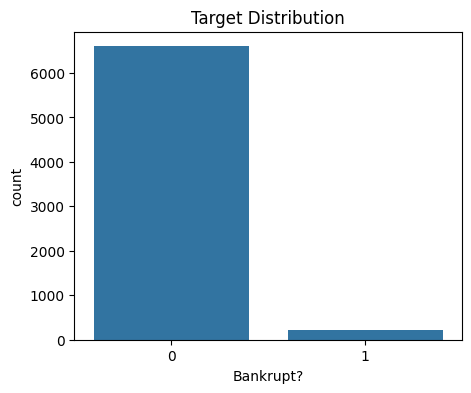

Observation: Bankruptcy cases are rare, so I will not use accuracy as my primary metric.


In [3]:
# EDA: dataset shape, target distribution, missing values, duplicate rows, and one simple visual of the target variable.

print("Dataset shape:", df.shape)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

target_counts = df[TARGET].value_counts().sort_index()
target_percent = df[TARGET].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "count": target_counts,
    "percent": target_percent.round(2)
})

display(target_summary)

missing_total = df.isna().sum().sum()
duplicate_rows = df.duplicated().sum()

print("Total missing values:", missing_total)
print("Duplicate rows:", duplicate_rows)

plt.figure(figsize=(5, 4))
sns.countplot(x="Bankrupt?", data=df)
plt.title("Target Distribution")
plt.show()

print(
    "Observation: Bankruptcy cases are rare, so I will not use accuracy as my primary metric."
)

<span style="font-size:20px"><b>EDA Notes</b></span><br/>
<span style="font-size:18px">
-Dataset has 6,819 rows and 96 columns. <br/>
-Target variable is highly imbalanced: 6,599 not bankrupt, 220 bankrupt. <br/>
-The positive class represents only 3.23% of the dataset.<br/>
-There are 0 missing values and 0 duplicate rows. <br/>
-All features are numeric — no categorical columns to encode. <br/>
-**Modeling implication**: accuracy is not useful here. A trivial "predict 0" model would score ~96.8% accuracy while catching zero bankruptcies. PR-AUC and Brier score will be used instead.
</span>

#### 3. Train, Validation, Test Split

In [4]:
RANDOM_STATE = 42

X = df.drop(columns=["Bankrupt?"])
y = df["Bankrupt?"]

X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE,
)

X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp_raw,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE,
)

print("Train shape:", X_train_raw.shape)
print("Validation shape:", X_val_raw.shape)
print("Test shape:", X_test_raw.shape)

def split_balance_table(name, y_split):
    counts = y_split.value_counts().sort_index()
    pct = (y_split.value_counts(normalize=True).sort_index() * 100).round(2)
    return pd.DataFrame(
        {
            "split": name,
            "class": counts.index,
            "count": counts.values,
            "percent": pct.values,
        }
    )

class_balance_df = pd.concat(
    [
        split_balance_table("Train", y_train),
        split_balance_table("Validation", y_val),
        split_balance_table("Test", y_test),
    ],
    ignore_index=True,
)

class_balance_df

Train shape: (4773, 95)
Validation shape: (1023, 95)
Test shape: (1023, 95)


,split,class,count,percent
0,Train,0,4619,96.77
1,Train,1,154,3.23
2,Validation,0,990,96.77
3,Validation,1,33,3.23
4,Test,0,990,96.77
5,Test,1,33,3.23


<span style="font-size:20px"><b>Split Notes</b></span><br/>
<span style="font-size:18px">
-Stratified 70/15/15 split preserves the ~3.23% positive rate across all three sets.<br/>
-**Test set will not be touched again until the final evaluation cell in Step 10.**<br/>
-Validation set is used for model comparison and threshold selection.
</span>

#### 4. Preprocessing

- This section checks the data types, missing values, whether any categorical columns exist, and whether any constant columns should be removed. 
- The template uses `get_dummies` after the split so the feature matrices are numeric for both Logistic Regression and XGBoost. 
- Preprocessing decisions are based on `X_train_raw`, not the full `X`, to avoid leakage from the validation and test sets.


In [5]:
print("Target removed from features:", "Bankrupt?" not in X_train_raw.columns)
print("\nDtypes summary:\n", X_train_raw.dtypes.value_counts())

# Check Missing Values
print("\nMissing values in train:", int(X_train_raw.isna().sum().sum()))

# Check Feature Types
categorical_cols = X_train_raw.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
print("\nCategorical columns:", categorical_cols if categorical_cols else "None")

print("\nLeakage check note: review column names manually and remove any obvious leakage columns if found.")

X_train = pd.get_dummies(X_train_raw, drop_first=False)
X_val = pd.get_dummies(X_val_raw, drop_first=False)
X_test = pd.get_dummies(X_test_raw, drop_first=False)

X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print("\nTrain cleaned shape:", X_train.shape)
print("Validation cleaned shape:", X_val.shape)
print("Test cleaned shape:", X_test.shape)


Target removed from features: True

Dtypes summary:
 float64    93
int64       2
Name: count, dtype: int64

Missing values in train: 0

Categorical columns: None

Leakage check note: review column names manually and remove any obvious leakage columns if found.

Train cleaned shape: (4773, 95)
Validation cleaned shape: (1023, 95)
Test cleaned shape: (1023, 95)


<span style="font-size:20px"><b>Preprocessing Notes</b></span><br/>
<span style="font-size:18px">
-Target `Bankrupt?` is removed from the feature matrix. <br/>
-No categorical features present — no encoding needed.<br/>
-No missing values in any split.<br/>
-Scaling is applied only for logistic regression. XGBoost is not affected by feature scale.<br/>
-No obvious leakage column names found.
</span>

### 5. Feature Sets

- Feature Set A: all usable features after basic cleaning
- Feature Set B: top 25 features selected using XGBoost feature importance on the training set only


In [6]:
feature_set_a = X_train.columns.tolist()
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

selector_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    eval_metric="logloss",
)
selector_model.fit(X_train[feature_set_a], y_train)

importances = pd.Series(selector_model.feature_importances_, index=feature_set_a)
feature_set_b = importances.sort_values(ascending=False).head(25).index.tolist()

print("Feature Set A size:", len(feature_set_a))
print("Feature Set B size:", len(feature_set_b))
print("\nTop 25 selected features:")
display(feature_set_b)


Feature Set A size: 95
Feature Set B size: 25

Top 25 selected features:


[' Persistent EPS in the Last Four Seasons',
 ' Liability to Equity',
 ' Equity to Liability',
 ' Net Value Growth Rate',
 ' Borrowing dependency',
 ' Continuous interest rate (after tax)',
 ' Net worth/Assets',
 ' Net Income to Total Assets',
 ' Quick Ratio',
 ' Non-industry income and expenditure/revenue',
 ' Debt ratio %',
 ' Total debt/Total net worth',
 ' ROA(B) before interest and depreciation after tax',
 ' Net Value Per Share (B)',
 ' Net Value Per Share (A)',
 ' Retained Earnings to Total Assets',
 ' Cash flow rate',
 ' Per Share Net profit before tax (Yuan ¥)',
 ' Net profit before tax/Paid-in capital',
 ' Cash Flow to Liability',
 ' Interest-bearing debt interest rate',
 " Net Income to Stockholder's Equity",
 ' Equity to Long-term Liability',
 ' ROA(C) before interest and depreciation before interest',
 ' Current Liability to Assets']

<span style="font-size:20px"><b>Feature Set Notes</b></span> <br/>
<span style="font-size:18px">
- Feature Set A keeps all 94 cleaned features.<br/>
- Feature Set B keeps the top 25 features by XGBoost gain importance.<br/>
- The selector was fit **only on training data**. Validation and test sets were not used.<br/>
- Feature Set B is easier to explain and may reduce noise, but its PR-AUC will be compared against Feature Set A in Experiment 5.
</span>

### 6. Reusable Evaluation Function

All five experiments use the same evaluation logic. Keep the threshold at `0.5` here so threshold choice does not affect model selection.


In [7]:
def evaluate_model(
    exp_id,
    model_name,
    model,
    X_train_use,
    y_train_use,
    X_val_use,
    y_val_use,
    feature_set_label,
    main_settings,
    threshold=0.5,
):
    model.fit(X_train_use, y_train_use)

    train_probs = model.predict_proba(X_train_use)[:, 1]
    val_probs = model.predict_proba(X_val_use)[:, 1]
    val_preds = (val_probs >= threshold).astype(int)

    train_pr_auc = average_precision_score(y_train_use, train_probs)
    val_pr_auc = average_precision_score(y_val_use, val_probs)

    result = {
        "exp_id": exp_id,
        "model": model_name,
        "feature_set": feature_set_label,
        "main_settings": main_settings,
        "train_pr_auc": train_pr_auc,
        "val_pr_auc": val_pr_auc,
        "overfit_gap": train_pr_auc - val_pr_auc,
        "val_roc_auc": roc_auc_score(y_val_use, val_probs),
        "val_brier": brier_score_loss(y_val_use, val_probs),
        "threshold": threshold,
        "val_precision": precision_score(y_val_use, val_preds, zero_division=0),
        "val_recall": recall_score(y_val_use, val_preds, zero_division=0),
        "val_f1_or_f2": fbeta_score(y_val_use, val_preds, beta=2, zero_division=0),
        "selected_finalist": "No",
        "notes": "",
    }

    return result, model, val_probs


## 7. The Five Required Experiments

All experiments below use `threshold = 0.5` in the results table.

1. Logistic Regression baseline on Feature Set A
2. XGBoost baseline on Feature Set A
3. XGBoost with imbalance handling on Feature Set A
4. Lightly tuned XGBoost on Feature Set A
5. XGBoost using selected Feature Set B


In [8]:
logreg_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE)),
])

xgb_exp2 = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    eval_metric="logloss",
)

xgb_exp3 = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    eval_metric="logloss",
)

xgb_exp4 = XGBClassifier(
    n_estimators=400,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.9,
    colsample_bytree=0.7,
    reg_lambda=2.0,
    gamma=0.1,
    random_state=RANDOM_STATE,
    eval_metric="logloss",
)

xgb_exp5 = XGBClassifier(
    n_estimators=250,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=2.0,
    gamma=0.1,
    random_state=RANDOM_STATE,
    eval_metric="logloss",
)

results = []
saved_models = {}
saved_val_probs = {}
saved_feature_sets = {}

row1, model1, probs1 = evaluate_model(
    1,
    "Logistic Regression",
    logreg_pipeline,
    X_train[feature_set_a],
    y_train,
    X_val[feature_set_a],
    y_val,
    "A",
    "class_weight=balanced, scaled inputs",
    threshold=EXPERIMENT_THRESHOLD,
)
row1["notes"] = "simple baseline"
results.append(row1)
saved_models[1] = model1
saved_val_probs[1] = probs1
saved_feature_sets[1] = feature_set_a

row2, model2, probs2 = evaluate_model(
    2,
    "XGBoost Baseline",
    xgb_exp2,
    X_train[feature_set_a],
    y_train,
    X_val[feature_set_a],
    y_val,
    "A",
    "200 trees, depth=4, lr=0.05",
    threshold=EXPERIMENT_THRESHOLD,
)
row2["notes"] = "baseline XGBoost"
results.append(row2)
saved_models[2] = model2
saved_val_probs[2] = probs2
saved_feature_sets[2] = feature_set_a

row3, model3, probs3 = evaluate_model(
    3,
    "XGBoost Imbalance",
    xgb_exp3,
    X_train[feature_set_a],
    y_train,
    X_val[feature_set_a],
    y_val,
    "A",
    "baseline + scale_pos_weight",
    threshold=EXPERIMENT_THRESHOLD,
)
row3["notes"] = "imbalance handling added"
results.append(row3)
saved_models[3] = model3
saved_val_probs[3] = probs3
saved_feature_sets[3] = feature_set_a

row4, model4, probs4 = evaluate_model(
    4,
    "XGBoost Tuned",
    xgb_exp4,
    X_train[feature_set_a],
    y_train,
    X_val[feature_set_a],
    y_val,
    "A",
    "400 trees, depth=3, lr=0.03, subsample=0.9, colsample=0.7",
    threshold=EXPERIMENT_THRESHOLD,
)
row4["notes"] = "light tuning across core parameters"
results.append(row4)
saved_models[4] = model4
saved_val_probs[4] = probs4
saved_feature_sets[4] = feature_set_a

row5, model5, probs5 = evaluate_model(
    5,
    "XGBoost Selected Features",
    xgb_exp5,
    X_train[feature_set_b],
    y_train,
    X_val[feature_set_b],
    y_val,
    "B",
    "top 25 features, depth=3, gamma=0.1, reg_lambda=2.0",
    threshold=EXPERIMENT_THRESHOLD,
)
row5["notes"] = "smaller feature set"
results.append(row5)
saved_models[5] = model5
saved_val_probs[5] = probs5
saved_feature_sets[5] = feature_set_b

results_df = pd.DataFrame(results)
results_df


,exp_id,model,feature_set,main_settings,train_pr_auc,val_pr_auc,overfit_gap,val_roc_auc,val_brier,threshold,val_precision,val_recall,val_f1_or_f2,selected_finalist,notes
0,1,Logistic Regression,A,"class_weight=balanced, scaled inputs",0.475510,0.272934,0.202576,0.885246,0.093401,0.5,0.176871,0.787879,0.465950,No,simple baseline
1,2,XGBoost Baseline,A,"200 trees, depth=4, lr=0.05",1.000000,0.599302,0.400698,0.964065,0.019827,0.5,0.714286,0.303030,0.342466,No,baseline XGBoost
2,3,XGBoost Imbalance,A,baseline + scale_pos_weight,0.999363,0.491467,0.507895,0.961004,0.029321,0.5,0.407407,0.666667,0.591398,No,imbalance handling added
3,4,XGBoost Tuned,A,"400 trees, depth=3, lr=0.03, subsample=0.9, co...",0.984699,0.615287,0.369412,0.965871,0.018926,0.5,0.769231,0.303030,0.344828,No,light tuning across core parameters
4,5,XGBoost Selected Features,B,"top 25 features, depth=3, gamma=0.1, reg_lambd...",0.909587,0.514508,0.395079,0.962381,0.021198,0.5,0.692308,0.272727,0.310345,No,smaller feature set


## 8. Model Selection Using Validation Only

Final model selection rule:

1. Best validation `PR-AUC`
2. Better validation `Brier score` when `PR-AUC` is similar
3. Reasonable `overfit_gap`
4. Simpler model if performance is still similar
5. No test results used here


In [9]:
results_df = results_df.sort_values(by=["val_pr_auc", "val_brier"], ascending=[False, True]).reset_index(drop=True)
winner_exp_id = int(results_df.loc[0, "exp_id"])
results_df["selected_finalist"] = np.where(results_df["exp_id"] == winner_exp_id, "Yes", "No")
results_df


,exp_id,model,feature_set,main_settings,train_pr_auc,val_pr_auc,overfit_gap,val_roc_auc,val_brier,threshold,val_precision,val_recall,val_f1_or_f2,selected_finalist,notes
0,4,XGBoost Tuned,A,"400 trees, depth=3, lr=0.03, subsample=0.9, co...",0.984699,0.615287,0.369412,0.965871,0.018926,0.5,0.769231,0.303030,0.344828,Yes,light tuning across core parameters
1,2,XGBoost Baseline,A,"200 trees, depth=4, lr=0.05",1.000000,0.599302,0.400698,0.964065,0.019827,0.5,0.714286,0.303030,0.342466,No,baseline XGBoost
2,5,XGBoost Selected Features,B,"top 25 features, depth=3, gamma=0.1, reg_lambd...",0.909587,0.514508,0.395079,0.962381,0.021198,0.5,0.692308,0.272727,0.310345,No,smaller feature set
3,3,XGBoost Imbalance,A,baseline + scale_pos_weight,0.999363,0.491467,0.507895,0.961004,0.029321,0.5,0.407407,0.666667,0.591398,No,imbalance handling added
4,1,Logistic Regression,A,"class_weight=balanced, scaled inputs",0.475510,0.272934,0.202576,0.885246,0.093401,0.5,0.176871,0.787879,0.465950,No,simple baseline


## 9. Threshold Selection for the Final Model Only

All five experiments above used `0.5`. Now that the winner is chosen, select one threshold on the validation set only.

Recommended strategy: choose the threshold that gives the best validation `F2-score` because false negatives matter more than false positives.


In [10]:
winner_val_probs = saved_val_probs[winner_exp_id]
threshold_grid = np.round(np.arange(0.05, 0.96, 0.05), 2)

threshold_results = []
for threshold in threshold_grid:
    preds = (winner_val_probs >= threshold).astype(int)
    threshold_results.append(
        {
            "threshold": threshold,
            "precision": precision_score(y_val, preds, zero_division=0),
            "recall": recall_score(y_val, preds, zero_division=0),
            "f2": fbeta_score(y_val, preds, beta=2, zero_division=0),
        }
    )

threshold_df = pd.DataFrame(threshold_results).sort_values(by="f2", ascending=False).reset_index(drop=True)
final_threshold = float(threshold_df.loc[0, "threshold"])

print("Winning experiment:", winner_exp_id)
print("Chosen final threshold from validation only:", final_threshold)
threshold_df.head(10)


Winning experiment: 4
Chosen final threshold from validation only: 0.15


,threshold,precision,recall,f2
0,0.15,0.520000,0.787879,0.714286
1,0.10,0.409091,0.818182,0.681818
2,0.05,0.295918,0.878788,0.630435
3,0.20,0.512195,0.636364,0.606936
4,0.25,0.588235,0.606061,0.602410
5,0.30,0.571429,0.484848,0.500000
6,0.35,0.625000,0.454545,0.480769
7,0.40,0.736842,0.424242,0.463576
8,0.45,0.785714,0.333333,0.376712
9,0.50,0.769231,0.303030,0.344828


## 10. Final Test Evaluation

Only now do we evaluate the selected final model on the untouched test set.


In [11]:
winner_model = saved_models[winner_exp_id]
winner_features = saved_feature_sets[winner_exp_id]

test_probs = winner_model.predict_proba(X_test[winner_features])[:, 1]
test_preds = (test_probs >= final_threshold).astype(int)

test_metrics = {
    "test_pr_auc": average_precision_score(y_test, test_probs),
    "test_roc_auc": roc_auc_score(y_test, test_probs),
    "test_brier": brier_score_loss(y_test, test_probs),
    "test_precision": precision_score(y_test, test_preds, zero_division=0),
    "test_recall": recall_score(y_test, test_preds, zero_division=0),
    "test_f2": fbeta_score(y_test, test_preds, beta=2, zero_division=0),
    "final_threshold": final_threshold,
}

pd.DataFrame([test_metrics])


,test_pr_auc,test_roc_auc,test_brier,test_precision,test_recall,test_f2,final_threshold
0,0.540312,0.953352,0.021695,0.418605,0.545455,0.514286,0.15


In [12]:
cm = confusion_matrix(y_test, test_preds)
cm_df = pd.DataFrame(cm, index=["Actual 0", "Actual 1"], columns=["Pred 0", "Pred 1"])
cm_df


,Pred 0,Pred 1
Actual 0,965,25
Actual 1,15,18


## 11. Final Plots

Required plots:

- Precision-recall curve
- Calibration curve
- Confusion matrix reported above
- Feature importance plot
- ROC curve is optional extra context


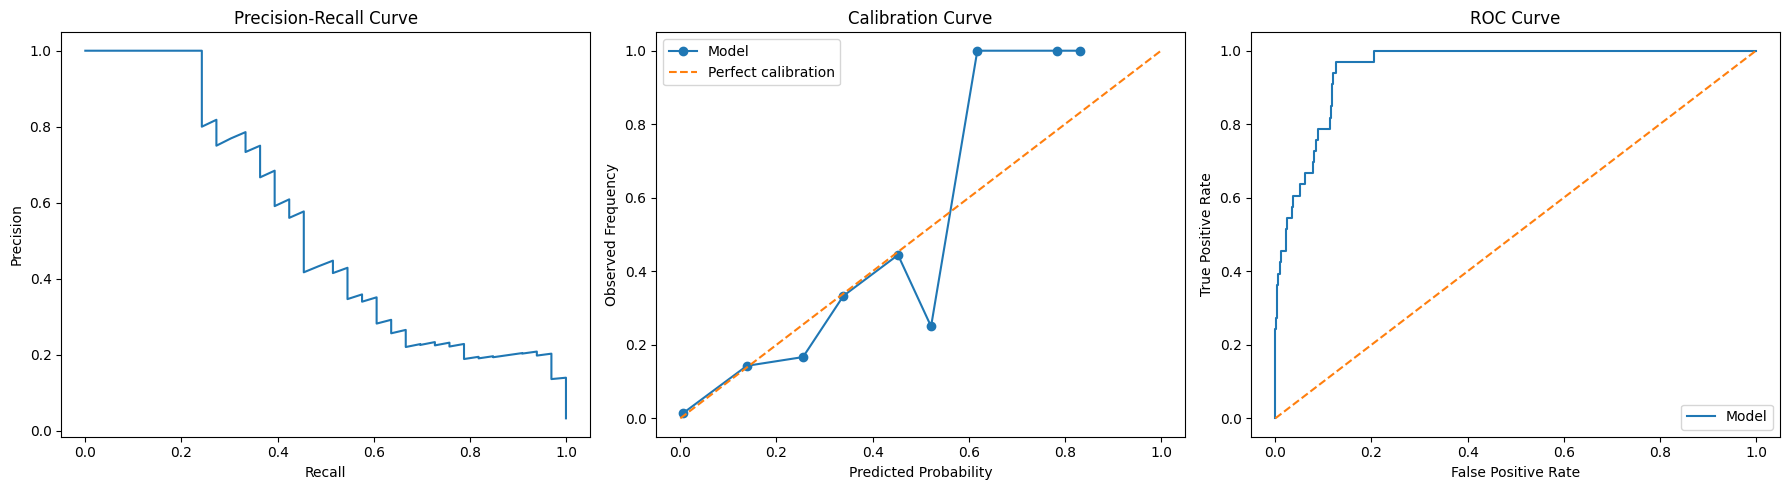

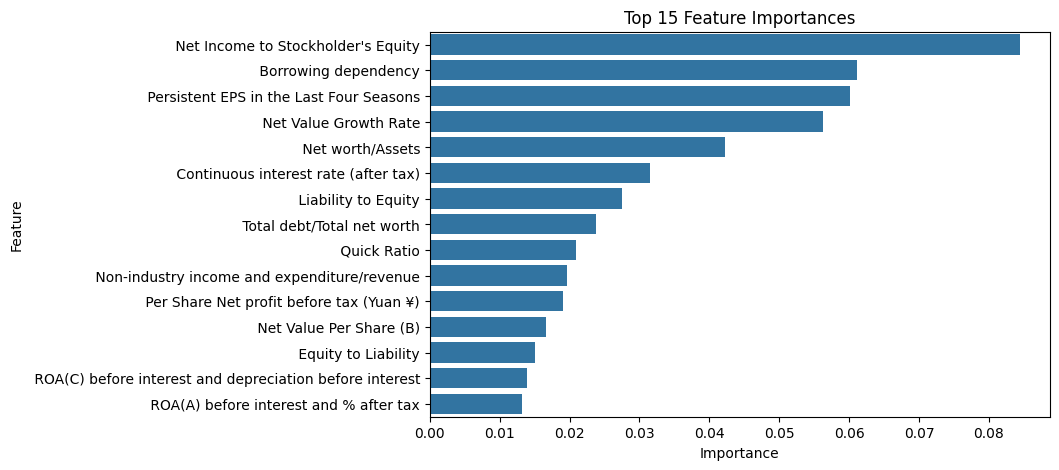

In [13]:
precision_vals, recall_vals, _ = precision_recall_curve(y_test, test_probs)
fpr, tpr, _ = roc_curve(y_test, test_probs)
prob_true, prob_pred = calibration_curve(y_test, test_probs, n_bins=10)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(recall_vals, precision_vals)
axes[0].set_title("Precision-Recall Curve")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")

axes[1].plot(prob_pred, prob_true, marker="o", label="Model")
axes[1].plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
axes[1].set_title("Calibration Curve")
axes[1].set_xlabel("Predicted Probability")
axes[1].set_ylabel("Observed Frequency")
axes[1].legend()

axes[2].plot(fpr, tpr, label="Model")
axes[2].plot([0, 1], [0, 1], linestyle="--")
axes[2].set_title("ROC Curve")
axes[2].set_xlabel("False Positive Rate")
axes[2].set_ylabel("True Positive Rate")
axes[2].legend()

plt.tight_layout()
plt.show()

if "XGBoost" in results_df.loc[results_df["selected_finalist"] == "Yes", "model"].iloc[0]:
    importance_series = pd.Series(
        winner_model.feature_importances_, index=winner_features
    ).sort_values(ascending=False).head(15)

    plt.figure(figsize=(8, 5))
    sns.barplot(x=importance_series.values, y=importance_series.index)
    plt.title("Top 15 Feature Importances")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.show()
